# SL-CBM Results — CUB with CREAM weights

In [11]:
import torch
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

# ── change this to your run folder ──────────────────────────────────────────
RUN_DIR = "/home/dani00003/sl-cbm/outputs/slcbm_cub_seed27/evaluations"
# ────────────────────────────────────────────────────────────────────────────

acc      = torch.load(f"{RUN_DIR}/accuracy.pt",              map_location="cpu")
adi      = torch.load(f"{RUN_DIR}/adi_pack.pt",              map_location="cpu")
nec      = torch.load(f"{RUN_DIR}/nec.pt",                   map_location="cpu")
interv   = torch.load(f"{RUN_DIR}/intervention_taskerror.pt",map_location="cpu")

print("Keys — accuracy:", list(acc.keys()))
print("Keys — adi_pack:", list(adi.keys()))
print("Keys — nec:",      list(nec.keys()))
print("Keys — intervention:", list(interv.keys()))

Keys — accuracy: ['test_acc', 'test_concept_acc']
Keys — adi_pack: ['concepts_avg_drop', 'concepts_avg_inc', 'concepts_avg_gain', 'classes_avg_drop', 'classes_avg_inc', 'classes_avg_gain']
Keys — nec: ['nec5', 'anec']
Keys — intervention: ['ag', 'rand', 'lcp', 'ucp', 'cctp']


## 1. Accuracy

In [12]:
print(f"Test Class Accuracy:   {acc['test_acc']:.2f}%")
print(f"Test Concept Accuracy: {acc['test_concept_acc']:.2f}%")

Test Class Accuracy:   69.66%
Test Concept Accuracy: 83.44%


## 2. Explainability — Average Drop / Increase / Gain (ADI)

In [13]:
import pandas as pd

adi_table = pd.DataFrame({
    "Level":    ["Concept", "Class"],
    "Avg Drop ↓": [
        round(float(adi["concepts_avg_drop"]) * 100, 2),
        round(float(adi["classes_avg_drop"])  * 100, 2),
    ],
    "Avg Inc ↑": [
        round(float(adi["concepts_avg_inc"]) * 100, 2),
        round(float(adi["classes_avg_inc"])  * 100, 2),
    ],
    "Avg Gain ↑": [
        round(float(adi["concepts_avg_gain"]) * 100, 2),
        round(float(adi["classes_avg_gain"])  * 100, 2),
    ],
})
print(adi_table.to_string(index=False))

  Level  Avg Drop ↓  Avg Inc ↑  Avg Gain ↑
Concept       14.94      41.56       24.42
  Class       13.40      42.30       24.55


## 3. Intervention — NEC / ANEC

In [14]:
print("NEC / ANEC scores:")
for k, v in nec.items():
    print(f"  {k}: {float(v):.4f}")

# correct key names
nec5_val = float(nec.get("nec5", nec.get("NEC-5", 0)))
anec_val = float(nec.get("anec", nec.get("ANEC", 0)))
print(f"\nNEC-5: {nec5_val:.2f}%  |  ANEC: {anec_val:.2f}%")

NEC / ANEC scores:
  nec5: 28.3900
  anec: 51.8983

NEC-5: 28.39%  |  ANEC: 51.90%


## 4. Intervention Curve (task error vs. # concepts corrected)

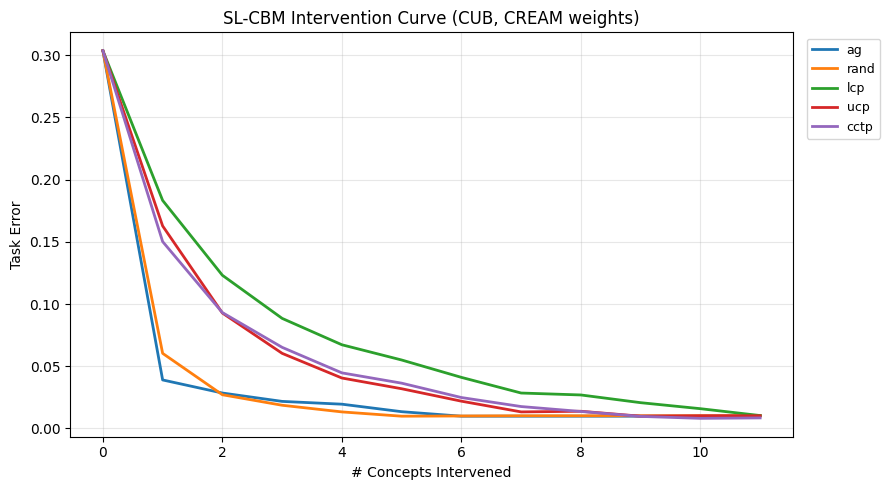

In [15]:
fig, ax = plt.subplots(figsize=(9, 5))

for method, tensor in interv.items():
    if isinstance(tensor, torch.Tensor):
        # shape: [n_batches, n_intervention_steps]
        # average task error across batches at each step
        if tensor.dim() == 2:
            y = tensor.mean(dim=0).numpy()
        else:
            y = tensor.numpy()
        x = np.arange(len(y))
        ax.plot(x, y, label=method, linewidth=2)

ax.set_xlabel("# Concepts Intervened")
ax.set_ylabel("Task Error")
ax.set_title("SL-CBM Intervention Curve (CUB, CREAM weights)")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{RUN_DIR}/intervention_curve.png", dpi=150, bbox_inches="tight")
plt.show()

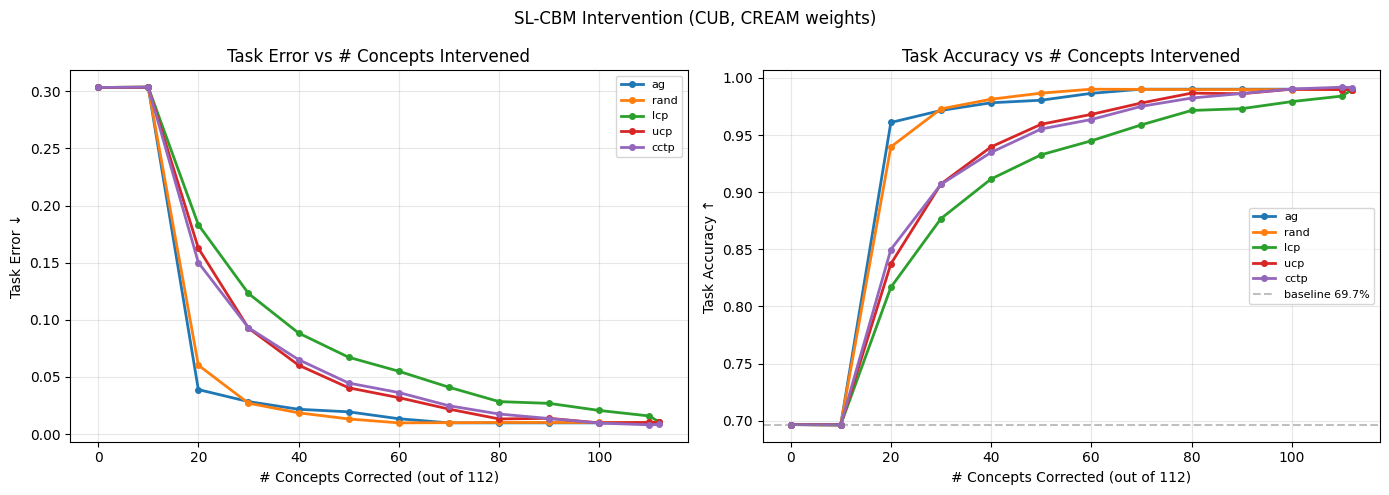

Baseline (no intervention):    69.66%
After correcting all concepts: 99.16%


In [16]:
baseline_acc   = float(acc["test_acc"]) / 100.0
baseline_error = 1.0 - baseline_acc

# actual concept counts at each intervention step (must match eval_utils.py call)
CUB_STEPS = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 112]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for method, tensor in interv.items():
    if not isinstance(tensor, torch.Tensor):
        continue
    y_error = tensor.mean(dim=0).numpy() if tensor.dim() == 2 else tensor.numpy()
    y_error_full = np.concatenate([[baseline_error], y_error])
    y_acc_full   = 1.0 - y_error_full

    x = CUB_STEPS[:len(y_error_full)]

    axes[0].plot(x, y_error_full, label=method, linewidth=2, marker="o", markersize=4)
    axes[1].plot(x, y_acc_full,   label=method, linewidth=2, marker="o", markersize=4)

axes[0].set_title("Task Error vs # Concepts Intervened")
axes[0].set_xlabel("# Concepts Corrected (out of 112)")
axes[0].set_ylabel("Task Error ↓")
axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3)

axes[1].set_title("Task Accuracy vs # Concepts Intervened")
axes[1].set_xlabel("# Concepts Corrected (out of 112)")
axes[1].set_ylabel("Task Accuracy ↑")
axes[1].axhline(y=baseline_acc, color="gray", linestyle="--", alpha=0.5,
                label=f"baseline {baseline_acc*100:.1f}%")
axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3)

plt.suptitle("SL-CBM Intervention (CUB, CREAM weights)", fontsize=12)
plt.tight_layout()
plt.savefig(f"{RUN_DIR}/intervention_curve_both.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Baseline (no intervention):    {baseline_acc*100:.2f}%")
print(f"After correcting all concepts: {y_acc_full[-1]*100:.2f}%")


## 5. Summary Table (copy into paper comparison)

In [17]:
nec5_val = float(nec.get("nec5", nec.get("NEC-5", 0)))
anec_val  = float(nec.get("anec", nec.get("ANEC",  0)))

summary = pd.DataFrame([{
    "Method":          "SL-CBM (CREAM)",
    "Class Acc":       round(float(acc["test_acc"]), 2),
    "Concept Acc":     round(float(acc["test_concept_acc"]), 2),
    "NEC-5":           round(nec5_val, 2),
    "ANEC":            round(anec_val, 2),
    "Concept AD↓":     round(float(adi["concepts_avg_drop"]) * 100, 2),
    "Concept AI↑":     round(float(adi["concepts_avg_inc"])  * 100, 2),
    "Concept AG↑":     round(float(adi["concepts_avg_gain"]) * 100, 2),
    "Class AD↓":       round(float(adi["classes_avg_drop"])  * 100, 2),
    "Class AI↑":       round(float(adi["classes_avg_inc"])   * 100, 2),
    "Class AG↑":       round(float(adi["classes_avg_gain"])  * 100, 2),
}])

print(summary.T.to_string(header=False))

Method       SL-CBM (CREAM)
Class Acc             69.66
Concept Acc           83.44
NEC-5                 28.39
ANEC                   51.9
Concept AD↓           14.94
Concept AI↑           41.56
Concept AG↑           24.42
Class AD↓              13.4
Class AI↑              42.3
Class AG↑             24.55


## 6. Top-5 Concept Groups by Classifier Weight

In [18]:
import sys, pickle
sys.path.insert(0, "/home/dani00003/sl-cbm")
sys.path.insert(0, "/home/dani00003/pcbm-module")

from utils.constants import CUB_features

CKPT_PATH = "/home/dani00003/sl-cbm/outputs/slcbm_cub_seed27/trainable_weights.pt"
CONCEPT_BANK_PATH = "/home/dani00003/sl-cbm/concept_banks/cub_resnet18_cream_0.1_100.pkl"

state = torch.load(CKPT_PATH, map_location="cpu")

W = state["classifier.1.weight"]   # [200, 112]
mean_abs_w = W.abs().mean(dim=0)   # [112]

with open(CONCEPT_BANK_PATH, "rb") as f:
    cb = pickle.load(f)

# keys are integers — map each to the CUB group name via CUB_features ranges
part_mask = CUB_features.part_mask  # list of 112 original attribute indices

def attr_idx_to_group(attr_idx):
    for group_name, (lo, hi) in vars(CUB_features).items():
        if group_name.startswith("has_") and isinstance(lo, int):
            if lo <= attr_idx <= hi:
                return group_name
    return str(attr_idx)

concept_names = [attr_idx_to_group(part_mask[i]) for i in range(len(part_mask))]
print(f"Total concepts: {len(concept_names)}")

top5_idx = mean_abs_w.topk(5).indices.tolist()
top5_concepts = [concept_names[i] for i in top5_idx]
print("\nTop-5 CUB concept groups by mean |classifier weight|:")
for rank, (idx, name) in enumerate(zip(top5_idx, top5_concepts), 1):
    print(f"  {rank}. [concept {idx}, attr {part_mask[idx]}] {name}  (weight={mean_abs_w[idx]:.4f})")

print("\nCopy into submit_interpret.sh CONCEPTS array:")
# use the unique group names (deduplicated, preserving order)
seen = set()
unique_top5 = []
for c in top5_concepts:
    if c not in seen:
        seen.add(c)
        unique_top5.append(c)
print('CONCEPTS=(' + ' '.join(f'"{c}"' for c in unique_top5) + ')')


/home/dani00003/miniconda3/envs/sl-cbm/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


ValueError: too many values to unpack (expected 2)

# SL-CBM Results — AwA2 with ResNet101 ImageNet weights

In [2]:
RUN_DIR_AWA2 = "/home/dani00003/sl-cbm/outputs/slcbm_awa2_seed27/evaluations"

acc_a  = torch.load(f"{RUN_DIR_AWA2}/accuracy.pt", map_location="cpu")

try:
    adi_a = torch.load(f"{RUN_DIR_AWA2}/adi_pack.pt", map_location="cpu")
except FileNotFoundError:
    adi_a = None
    print("adi_pack.pt not found yet")

try:
    nec_a = torch.load(f"{RUN_DIR_AWA2}/nec.pt", map_location="cpu")
except FileNotFoundError:
    nec_a = None
    print("nec.pt not found yet — resubmit eval job")

try:
    interv_a = torch.load(f"{RUN_DIR_AWA2}/intervention_taskerror.pt", map_location="cpu")
except FileNotFoundError:
    interv_a = None
    print("intervention_taskerror.pt not found yet — resubmit eval job")

print("Keys — accuracy:", list(acc_a.keys()))
if adi_a:   print("Keys — adi_pack:", list(adi_a.keys()))
if nec_a:   print("Keys — nec:",      list(nec_a.keys()))
if interv_a: print("Keys — intervention:", list(interv_a.keys()))


Keys — accuracy: ['test_acc', 'test_concept_acc']
Keys — adi_pack: ['concepts_avg_drop', 'concepts_avg_inc', 'concepts_avg_gain', 'classes_avg_drop', 'classes_avg_inc', 'classes_avg_gain']
Keys — nec: ['nec5', 'anec']
Keys — intervention: ['ag', 'rand', 'lcp', 'ucp', 'cctp']


## A1. Accuracy

In [3]:
print(f"Test Class Accuracy:   {acc_a['test_acc']:.2f}%")
print(f"Test Concept Accuracy: {acc_a['test_concept_acc']:.2f}%")


Test Class Accuracy:   89.66%
Test Concept Accuracy: 95.83%


## A2. Explainability — ADI

In [5]:
import pandas as pd

if adi_a:
    adi_table_a = pd.DataFrame({
        "Level":      ["Concept", "Class"],
        "Avg Drop ↓": [round(float(adi_a["concepts_avg_drop"]) * 100, 2),
                       round(float(adi_a["classes_avg_drop"])  * 100, 2)],
        "Avg Inc ↑":  [round(float(adi_a["concepts_avg_inc"])  * 100, 2),
                       round(float(adi_a["classes_avg_inc"])   * 100, 2)],
        "Avg Gain ↑": [round(float(adi_a["concepts_avg_gain"]) * 100, 2),
                       round(float(adi_a["classes_avg_gain"])  * 100, 2)],
    })
    print(adi_table_a.to_string(index=False))
else:
    print("ADI not available yet")


  Level  Avg Drop ↓  Avg Inc ↑  Avg Gain ↑
Concept        5.06      41.48       35.52
  Class        4.73      41.63       36.33


## A3. Intervention — NEC / ANEC

In [6]:
if nec_a:
    nec5_a = float(nec_a.get("nec5", nec_a.get("NEC-5", 0)))
    anec_a = float(nec_a.get("anec", nec_a.get("ANEC",  0)))
    print(f"NEC-5: {nec5_a:.2f}%  |  ANEC: {anec_a:.2f}%")
else:
    nec5_a = anec_a = None
    print("NEC not available yet — resubmit eval job with --evaluate flag")


NEC-5: 59.63%  |  ANEC: 80.64%


## A4. Intervention Curve

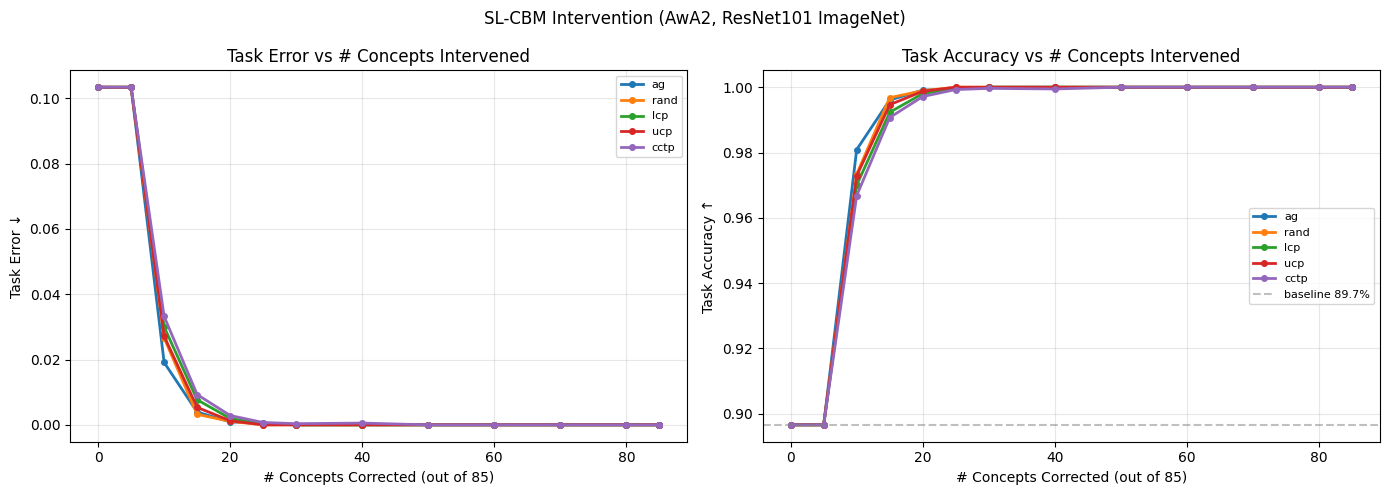

Baseline: 89.66%  |  After all interventions: 100.00%


In [7]:
if interv_a:
    baseline_acc_a   = float(acc_a["test_acc"]) / 100.0
    baseline_error_a = 1.0 - baseline_acc_a

    # actual concept counts at each step (must match eval_utils.py awa2 call)
    AWA2_STEPS = [0, 5, 10, 15, 20, 25, 30, 40, 50, 60, 70, 80, 85, 85]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for method, tensor in interv_a.items():
        if not isinstance(tensor, torch.Tensor):
            continue
        y_error = tensor.mean(dim=0).numpy() if tensor.dim() == 2 else tensor.numpy()
        y_error_full = np.concatenate([[baseline_error_a], y_error])
        y_acc_full   = 1.0 - y_error_full
        x = AWA2_STEPS[:len(y_error_full)]

        axes[0].plot(x, y_error_full, label=method, linewidth=2, marker="o", markersize=4)
        axes[1].plot(x, y_acc_full,   label=method, linewidth=2, marker="o", markersize=4)

    axes[0].set_title("Task Error vs # Concepts Intervened")
    axes[0].set_xlabel("# Concepts Corrected (out of 85)")
    axes[0].set_ylabel("Task Error ↓")
    axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3)

    axes[1].set_title("Task Accuracy vs # Concepts Intervened")
    axes[1].set_xlabel("# Concepts Corrected (out of 85)")
    axes[1].set_ylabel("Task Accuracy ↑")
    axes[1].axhline(y=baseline_acc_a, color="gray", linestyle="--", alpha=0.5,
                    label=f"baseline {baseline_acc_a*100:.1f}%")
    axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3)

    plt.suptitle("SL-CBM Intervention (AwA2, ResNet101 ImageNet)", fontsize=12)
    plt.tight_layout()
    plt.savefig(f"{RUN_DIR_AWA2}/intervention_curve_both.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Baseline: {baseline_acc_a*100:.2f}%  |  After all interventions: {y_acc_full[-1]*100:.2f}%")
else:
    print("Intervention data not available yet — resubmit eval job with --evaluate flag")


## A5. Top-5 Concept Groups by Classifier Weight (AwA2)

In [9]:
import sys, pickle
sys.path.insert(0, "/home/dani00003/sl-cbm")
sys.path.insert(0, "/home/dani00003/pcbm-module")


CKPT_PATH_AWA2 = "/home/dani00003/sl-cbm/outputs/slcbm_awa2_seed42/trainable_weights.pt"
CONCEPT_BANK_AWA2 = "/home/dani00003/sl-cbm/concept_banks/awa2_resnet101_imagenet_0.1_236.pkl"

state_a = torch.load(CKPT_PATH_AWA2, map_location="cpu")

W_a = state_a["classifier.1.weight"]   # [50, 85]
mean_abs_w_a = W_a.abs().mean(dim=0)   # [85]

with open(CONCEPT_BANK_AWA2, "rb") as f:
    cb_a = pickle.load(f)

# concept bank is a dict — keys are concept names
concept_names_a = list(cb_a.keys())
print(f"Total AwA2 concepts: {len(concept_names_a)}")

top5_idx_a = mean_abs_w_a.topk(5).indices.tolist()
top5_concepts_a = [concept_names_a[i] for i in top5_idx_a]
print("\nTop-5 AwA2 concepts by mean |classifier weight|:")
for rank, (idx, name) in enumerate(zip(top5_idx_a, top5_concepts_a), 1):
    print(f"  {rank}. [{idx}] {name}  (weight={mean_abs_w_a[idx]:.4f})")

print("\nCopy into submit_interpret_awa2.sh CONCEPTS array:")
print('CONCEPTS=(' + ' '.join(f'"{c}"' for c in top5_concepts_a) + ')')


Total AwA2 concepts: 85

Top-5 AwA2 concepts by mean |classifier weight|:
  1. [25] 26	tail  (weight=0.2319)
  2. [10] 11	stripes  (weight=0.2294)
  3. [3] 4	brown  (weight=0.2291)
  4. [0] 1	black  (weight=0.2289)
  5. [41] 42	strong  (weight=0.2267)

Copy into submit_interpret_awa2.sh CONCEPTS array:
CONCEPTS=("26	tail" "11	stripes" "4	brown" "1	black" "42	strong")


# CUB vs AwA2 — Side-by-Side Comparison

In [15]:
rows = []

# CUB row (always available)
rows.append({
    "Dataset":      "CUB-200 (CREAM)",
    "Backbone":     "ResNet18",
    "Classes":      200,
    "Concepts":     112,
    "Class Acc":    round(float(acc["test_acc"]), 2),
    "Concept Acc":  round(float(acc["test_concept_acc"]), 2),
    "NEC-5":        round(float(nec.get("nec5", 0)), 2),
    "ANEC":         round(float(nec.get("anec",  0)), 2),
    "Concept AD↓":  round(float(adi["concepts_avg_drop"]) * 100, 2),
    "Concept AI↑":  round(float(adi["concepts_avg_inc"])  * 100, 2),
    "Concept AG↑":  round(float(adi["concepts_avg_gain"]) * 100, 2),
    "Class AD↓":    round(float(adi["classes_avg_drop"])  * 100, 2),
    "Class AI↑":    round(float(adi["classes_avg_inc"])   * 100, 2),
    "Class AG↑":    round(float(adi["classes_avg_gain"])  * 100, 2),
})

# AwA2 row
awa2_row = {
    "Dataset":      "AwA2 (ImageNet)",
    "Backbone":     "ResNet101",
    "Classes":      50,
    "Concepts":     85,
    "Class Acc":    round(float(acc_a["test_acc"]), 2),
    "Concept Acc":  round(float(acc_a["test_concept_acc"]), 2),
    "NEC-5":        round(nec5_a, 2) if nec5_a is not None else "N/A",
    "ANEC":         round(anec_a, 2) if anec_a is not None else "N/A",
}
if adi_a:
    awa2_row.update({
        "Concept AD↓": round(float(adi_a["concepts_avg_drop"]) * 100, 2),
        "Concept AI↑": round(float(adi_a["concepts_avg_inc"])  * 100, 2),
        "Concept AG↑": round(float(adi_a["concepts_avg_gain"]) * 100, 2),
        "Class AD↓":   round(float(adi_a["classes_avg_drop"])  * 100, 2),
        "Class AI↑":   round(float(adi_a["classes_avg_inc"])   * 100, 2),
        "Class AG↑":   round(float(adi_a["classes_avg_gain"])  * 100, 2),
    })
else:
    for k in ["Concept AD↓","Concept AI↑","Concept AG↑","Class AD↓","Class AI↑","Class AG↑"]:
        awa2_row[k] = "N/A"
rows.append(awa2_row)

comparison = pd.DataFrame(rows).set_index("Dataset")
print(comparison.T.to_string())


Dataset     CUB-200 (CREAM) AwA2 (ImageNet)
Backbone           ResNet18       ResNet101
Classes                 200              50
Concepts                112              85
Class Acc             68.78            89.6
Concept Acc           82.68           96.03
NEC-5                 24.91           50.07
ANEC                  47.48           73.23
Concept AD↓           15.61            4.69
Concept AI↑            39.6           37.55
Concept AG↑           26.55           40.08
Class AD↓             14.98            4.76
Class AI↑              39.8           37.63
Class AG↑             26.56           40.35
